# **Spatial-Temporal Modeling of the Relationship between the Performance of the Beer industry and the Economy across the United States using Panel Time Series Modeling**

## API Call, Data Collection and Data Cleaning

### Open Breweries Data API

In [1]:
# Open Breweries Data API
import requests

base_url = "https://api.openbrewerydb.org/v1/breweries"

per_page = 200
total_pages = 10

all_breweries = []

for page in range(1, total_pages + 1):
    params = {
        "per_page": per_page,
        "page": page
    }

    response = requests.get(base_url, params=params)
    response.raise_for_status()
    breweries = response.json()

    all_breweries.extend(breweries)

print("Total breweries collected:", len(all_breweries))
print("First brewery:")
print(all_breweries[0])

Total breweries collected: 2000
First brewery:
{'id': '5128df48-79fc-4f0f-8b52-d06be54d0cec', 'name': '(405) Brewing Co', 'brewery_type': 'micro', 'address_1': '1716 Topeka St', 'address_2': None, 'address_3': None, 'city': 'Norman', 'state_province': 'Oklahoma', 'postal_code': '73069-8224', 'country': 'United States', 'longitude': -97.46818222, 'latitude': 35.25738891, 'phone': '4058160490', 'website_url': 'http://www.405brewing.com', 'state': 'Oklahoma', 'street': '1716 Topeka St'}


In [2]:
## Checking General Data Structure
all_breweries

[{'id': '5128df48-79fc-4f0f-8b52-d06be54d0cec',
  'name': '(405) Brewing Co',
  'brewery_type': 'micro',
  'address_1': '1716 Topeka St',
  'address_2': None,
  'address_3': None,
  'city': 'Norman',
  'state_province': 'Oklahoma',
  'postal_code': '73069-8224',
  'country': 'United States',
  'longitude': -97.46818222,
  'latitude': 35.25738891,
  'phone': '4058160490',
  'website_url': 'http://www.405brewing.com',
  'state': 'Oklahoma',
  'street': '1716 Topeka St'},
 {'id': '9c5a66c8-cc13-416f-a5d9-0a769c87d318',
  'name': '(512) Brewing Co',
  'brewery_type': 'micro',
  'address_1': '407 Radam Ln Ste F200',
  'address_2': None,
  'address_3': None,
  'city': 'Austin',
  'state_province': 'Texas',
  'postal_code': '78745-1197',
  'country': 'United States',
  'longitude': None,
  'latitude': None,
  'phone': '5129211545',
  'website_url': 'http://www.512brewing.com',
  'state': 'Texas',
  'street': '407 Radam Ln Ste F200'},
 {'id': '34e8c68b-6146-453f-a4b9-1f6cd99a5ada',
  'name': '

In [3]:
## Converting List of Dictionaries from JSON Data format to Pandas
import pandas as pd

breweries_df = pd.DataFrame(all_breweries)
breweries_df

,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,longitude,latitude,phone,website_url,state,street
0,5128df48-79fc-4f0f-8b52-d06be54d0cec,(405) Brewing Co,micro,1716 Topeka St,None,None,Norman,Oklahoma,73069-8224,United States,-97.468182,35.257389,4058160490,http://www.405brewing.com,Oklahoma,1716 Topeka St
1,9c5a66c8-cc13-416f-a5d9-0a769c87d318,(512) Brewing Co,micro,407 Radam Ln Ste F200,None,None,Austin,Texas,78745-1197,United States,NaN,NaN,5129211545,http://www.512brewing.com,Texas,407 Radam Ln Ste F200
2,34e8c68b-6146-453f-a4b9-1f6cd99a5ada,1 of Us Brewing Company,micro,8100 Washington Ave,None,None,Mount Pleasant,Wisconsin,53406-3920,United States,-87.883364,42.720108,2624847553,https://www.1ofusbrewing.com,Wisconsin,8100 Washington Ave
3,6d14b220-8926-4521-8d19-b98a2d6ec3db,10 Barrel Brewing Co,large,62970 18th St,None,None,Bend,Oregon,97701-9847,United States,-121.281706,44.086835,5415851007,http://www.10barrel.com,Oregon,62970 18th St
4,e2e78bd8-80ff-4a61-a65c-3bfbd9d76ce2,10 Barrel Brewing Co,large,1135 NW Galveston Ave Ste B,None,None,Bend,Oregon,97703-2465,United States,-121.328802,44.057565,5415851007,None,Oregon,1135 NW Galveston Ave Ste B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3c820163-0cdf-4f61-a2d7-bb294da08380,Chicago Beer Company,contract,1140 W Randolph St,None,None,Chicago,Illinois,60607-1619,United States,-87.655892,41.884340,7732448696,http://www.chicagobeerco.com,Illinois,1140 W Randolph St
1996,d1998a9b-eacd-439c-be7f-09b9b84fc95a,Chicago Brewing Co - NV,brewpub,2201 S Fort Apache Rd,None,None,Las Vegas,Nevada,89117-5704,United States,-115.298383,36.147587,7022543333,http://www.chicagobrewingcolv.com,Nevada,2201 S Fort Apache Rd
1997,653a1d3f-2589-46f0-b8f5-e76db412ae53,Chili Line Brewing Co.,brewpub,204 N. Guadalupe St.,None,None,Santa Fe,New Mexico,87501-1827,United States,-105.943531,35.689476,5055007903,http://www.chililinebrewery@gmail.com,New Mexico,204 N. Guadalupe St.
1998,0e0f9002-fe65-4484-a951-03045a1e08b1,CHILLAX Brewing Company LLC,planning,None,None,None,Milford,Michigan,48381-2243,United States,NaN,NaN,2483883458,None,Michigan,None


In [4]:
## Checking for missing entries
breweries_df.isnull().sum()

,0
id,0
name,0
brewery_type,0
address_1,145
address_2,1941
address_3,1989
city,0
state_province,0
postal_code,0
country,0


In [5]:
## Removing variables with high numbers of missing entries 48 and 59 respectively for address_2 and address_3
breweries_df = breweries_df.drop(columns=["address_2", "address_3"])

### Breweries Profile Rating Data

In [6]:
# Breweries Profile Rating Data

## Importing Data
file_path = "breweries_profile_ratings_df.csv"
breweries_profile_ratings_df = pd.read_csv(file_path)

## Getting Data Overview
breweries_profile_ratings_df

,Name,Style,Brewery,Beer Name (Full),Description,ABV,Min IBU,Max IBU,Astringency,Body,...,Fruits,Hoppy,Spices,Malty,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews
0,Amber,Altbier,Alaskan Brewing Co.,Alaskan Brewing Co. Alaskan Amber,"Notes:Richly malty and long on the palate, wit...",5.3,25,50,13,32,...,33,57,8,111,3.498994,3.636821,3.556338,3.643863,3.847082,497
1,Double Bag,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Double Bag,"Notes:This malty, full-bodied double alt is al...",7.2,25,50,12,57,...,24,35,12,84,3.798337,3.846154,3.904366,4.024948,4.034304,481
2,Long Trail Ale,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Long Trail Ale,Notes:Long Trail Ale is a full-bodied amber al...,5.0,25,50,14,37,...,10,54,4,62,3.409814,3.667109,3.600796,3.631300,3.830239,377
3,Doppelsticke,Altbier,Uerige Obergärige Hausbrauerei GmbH / Zum Uerige,Uerige Obergärige Hausbrauerei GmbH / Zum Ueri...,Notes:,8.5,25,50,13,55,...,49,40,16,119,4.148098,4.033967,4.150815,4.205163,4.005435,368
4,Sleigh'r Dark Doüble Alt Ale,Altbier,Ninkasi Brewing Company,Ninkasi Brewing Company Sleigh'r Dark Doüble A...,Notes:Called 'Dark Double Alt' on the label.Se...,7.2,25,50,25,51,...,11,51,20,95,3.625000,3.973958,3.734375,3.765625,3.817708,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,Winter Shredder,Winter Warmer,Cisco Brewers Inc.,Cisco Brewers Inc. Winter Shredder,Notes:,8.8,35,50,15,37,...,23,45,67,74,4.125000,3.875000,3.875000,3.750000,4.000000,4
3193,The First Snow Ale,Winter Warmer,RJ Rockers Brewing Company,RJ Rockers Brewing Company First Snow Ale,Notes:This hearty American pale ale contains a...,6.0,35,50,15,31,...,54,14,140,58,3.950000,3.750000,3.760000,3.790000,3.730000,50
3194,Red Nose Winter Ale,Winter Warmer,Natty Greene's Pub & Brewing Co.,Natty Greene's Pub & Brewing Co. Red Nose Wint...,Notes:,6.8,35,50,8,44,...,26,21,96,77,3.576923,3.711538,3.596154,3.673077,3.711538,26
3195,Fish Tale Winterfish,Winter Warmer,Fish Brewing Company / Fishbowl Brewpub,Fish Brewing Company / Fishbowl Brewpub Fish T...,Notes:,7.5,35,50,11,36,...,81,110,18,73,3.902299,3.885057,3.862069,3.902299,3.879310,87


### BEA API DATA

In [7]:
import requests
import pandas as pd

api_key = "********-****-****-****-************"
base_url = "https://apps.bea.gov/api/data"

params = {
    "UserID": api_key,
    "method": "GetData",
    "datasetname": "Regional",
    "TableName": "SAGDP2",
    "LineCode": "1",
    "GeoFips": "STATE",
    "Year": "2018,2019,2020,2021,2022,2023",
    "ResultFormat": "json"
}

response = requests.get(base_url, params=params)
data = response.json()

# Check if data exists
records = data.get("BEAAPI", {}).get("Results", {}).get("Data", [])

GDP_df = pd.DataFrame(records)
GDP_df = GDP_df[['GeoName','TimePeriod','DataValue']]
GDP_df.rename(columns={'GeoName':'State','TimePeriod':'Year','DataValue':'GDP'}, inplace=True)

# Removing United States total row
GDP_df = GDP_df[GDP_df['State'] != 'United States *']

GDP_df



,State,Year,GDP
6,Alabama,2023,309543.8
7,Alabama,2022,286873.3
8,Alabama,2021,260325.0
9,Alabama,2020,235859.0
10,Alabama,2019,234798.2
...,...,...,...
355,Far West,2019,4258455.7
356,Far West,2020,4254155.7
357,Far West,2021,4733129.8
358,Far West,2022,5058451.6


### FRED Household Data

In [8]:
# Getting Income Data Scrapped from FRED
Income1823 = pd.read_csv("Income2018_23.csv")
Income1823.head(10)

,Name,2018,2019,2020,2021,2022,2023
0,Alabama,"61,420","68,110","65,600","65,360","63,870","62,230"
1,Alaska,"84,540","95,010","89,650","93,150","95,670","100,700"
2,Arizona,"76,600","85,650","80,470","81,310","78,300","84,800"
3,Arkansas,"61,230","66,100","60,900","58,310","57,540","64,880"
4,California,"86,690","94,660","93,140","93,660","90,930","92,200"
5,Colorado,"89,820","87,870","100,500","97,540","95,870","99,140"
6,Connecticut,"89,550","105,800","95,280","92,950","96,720","94,620"
7,Delaware,"79,960","89,920","83,990","78,860","86,090","88,570"
8,District of Columbia,"105,500","112,800","105,800","104,100","108,400","113,900"
9,Florida,"67,210","70,740","69,280","68,580","69,680","74,070"


In [9]:
# Converting Income Data to Long Format

# Melting the DataFrame to long format
Income1823_long = Income1823.melt(id_vars="Name", var_name="Year", value_name="Value")

# Renaming Columns
Income1823_long.rename(columns={"Name": "State", "Value": "Household_Income"}, inplace=True)

Income1823_long.head(10)

,State,Year,Household_Income
0,Alabama,2018,"61,420"
1,Alaska,2018,"84,540"
2,Arizona,2018,"76,600"
3,Arkansas,2018,"61,230"
4,California,2018,"86,690"
5,Colorado,2018,"89,820"
6,Connecticut,2018,"89,550"
7,Delaware,2018,"79,960"
8,District of Columbia,2018,"105,500"
9,Florida,2018,"67,210"


## Merging Datasets

In [10]:
# Merging GDP data into Household Income data
merged_data = pd.merge(Income1823_long, GDP_df, on=["State", "Year"], how="left")

print(merged_data)

             State  Year Household_Income        GDP
0          Alabama  2018           61,420   226263.8
1           Alaska  2018           84,540    54762.0
2          Arizona  2018           76,600   353671.0
3         Arkansas  2018           61,230   129213.8
4       California  2018           86,690  2899530.9
..             ...   ...              ...        ...
301       Virginia  2023           98,990   722767.4
302     Washington  2023           95,850   801455.5
303  West Virginia  2023           61,970   101479.9
304      Wisconsin  2023           81,750   431913.9
305        Wyoming  2023           79,200    51350.1

[306 rows x 4 columns]


In [11]:
# Counting the number of breweries per state
# Count breweries per state with data filtered for the US
state_counts = (
    breweries_df[breweries_df["country"] == "United States"]
    .groupby("state")
    .size()
    .reset_index(name="brewery_count")
)

state_counts.head()

,state,brewery_count
0,Alabama,18
1,Alaska,14
2,Arizona,20
3,Arkansas,9
4,California,189


In [12]:
# Adding the number of breweries per state to the merged data
merged_data = pd.merge(merged_data, state_counts, left_on="State", right_on="state", how="left")
merged_data.drop(columns="state", inplace=True)
merged_data.head()

,State,Year,Household_Income,GDP,brewery_count
0,Alabama,2018,"61,420",226263.8,18
1,Alaska,2018,"84,540",54762.0,14
2,Arizona,2018,"76,600",353671.0,20
3,Arkansas,2018,"61,230",129213.8,9
4,California,2018,"86,690",2899530.9,189


In [13]:
# Replacing NaNs with 0
merged_data["brewery_count"] = merged_data["brewery_count"].fillna(0).astype(int)
merged_data.head()

,State,Year,Household_Income,GDP,brewery_count
0,Alabama,2018,"61,420",226263.8,18
1,Alaska,2018,"84,540",54762.0,14
2,Arizona,2018,"76,600",353671.0,20
3,Arkansas,2018,"61,230",129213.8,9
4,California,2018,"86,690",2899530.9,189


## Exploratory Data Analysis (EDA)

### Trend Analysis

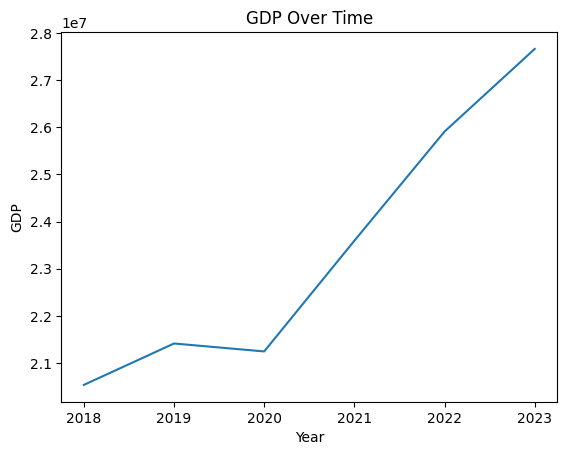

In [14]:
# Fixing Data Type for GDP
merged_data["GDP"] = (
    merged_data["GDP"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Grouping GDP data by year
gdp_year = (
    merged_data.groupby("Year", as_index=False)["GDP"]
      .sum()
)

# Plotting the the trend in National GDP

import matplotlib.pyplot as plt

plt.figure()
plt.plot(gdp_year["Year"], gdp_year["GDP"])
plt.xlabel("Year")
plt.ylabel("GDP")
plt.title("GDP Over Time")
plt.show()

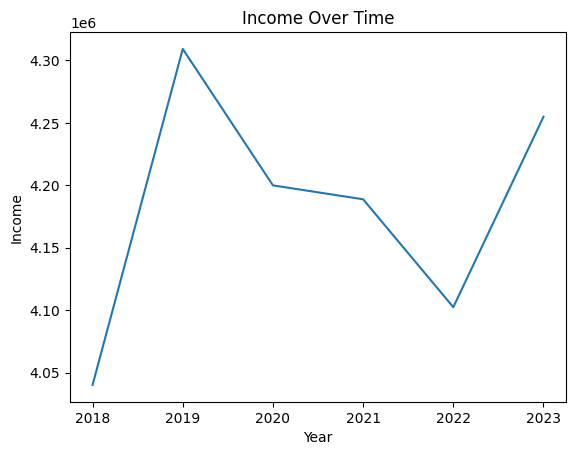

In [15]:
# Fixing Data Type for income
merged_data["Household_Income"] = (
    merged_data["Household_Income"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Grouping GDP data by year
income_year = (
    merged_data.groupby("Year", as_index=False)["Household_Income"]
      .sum()
)

# Plotting the the trend in National GDP

import matplotlib.pyplot as plt

plt.figure()
plt.plot(income_year["Year"], income_year["Household_Income"])
plt.xlabel("Year")
plt.ylabel("Income")
plt.title("Income Over Time")
plt.show()

## Spatial Analysis

### Data Preparation for Spatial Analysis

In [16]:
# Getting polygon mapping data from GEOJSON
import geopandas as gpd

geojson_url = "https://raw.githubusercontent.com/AndreiKingsley/datasets/refs/heads/main/USA.json"

# Loading US states polygons
states = gpd.read_file(geojson_url)

print(states.head())

   id        name                                           geometry
0  01     Alabama  POLYGON ((-87.3593 35.00118, -85.60668 34.9847...
1  02      Alaska  MULTIPOLYGON (((-131.60202 55.11798, -131.5691...
2  04     Arizona  POLYGON ((-109.0425 37.00026, -109.04798 31.33...
3  05    Arkansas  POLYGON ((-94.47384 36.50186, -90.15254 36.496...
4  06  California  POLYGON ((-123.23326 42.00619, -122.37885 42.0...


In [17]:
# Merging the counts and spatial data
states = states.merge(
    state_counts,
    left_on="name",
    right_on="state",
    how="left"
)
print(states.head())

   id        name                                           geometry  \
0  01     Alabama  POLYGON ((-87.3593 35.00118, -85.60668 34.9847...   
1  02      Alaska  MULTIPOLYGON (((-131.60202 55.11798, -131.5691...   
2  04     Arizona  POLYGON ((-109.0425 37.00026, -109.04798 31.33...   
3  05    Arkansas  POLYGON ((-94.47384 36.50186, -90.15254 36.496...   
4  06  California  POLYGON ((-123.23326 42.00619, -122.37885 42.0...   

        state  brewery_count  
0     Alabama           18.0  
1      Alaska           14.0  
2     Arizona           20.0  
3    Arkansas            9.0  
4  California          189.0  


In [18]:
# Replace NaNs with 0
states["brewery_count"] = states["brewery_count"].fillna(0)
print(states.head())

   id        name                                           geometry  \
0  01     Alabama  POLYGON ((-87.3593 35.00118, -85.60668 34.9847...   
1  02      Alaska  MULTIPOLYGON (((-131.60202 55.11798, -131.5691...   
2  04     Arizona  POLYGON ((-109.0425 37.00026, -109.04798 31.33...   
3  05    Arkansas  POLYGON ((-94.47384 36.50186, -90.15254 36.496...   
4  06  California  POLYGON ((-123.23326 42.00619, -122.37885 42.0...   

        state  brewery_count  
0     Alabama           18.0  
1      Alaska           14.0  
2     Arizona           20.0  
3    Arkansas            9.0  
4  California          189.0  


### Spatial Analysis

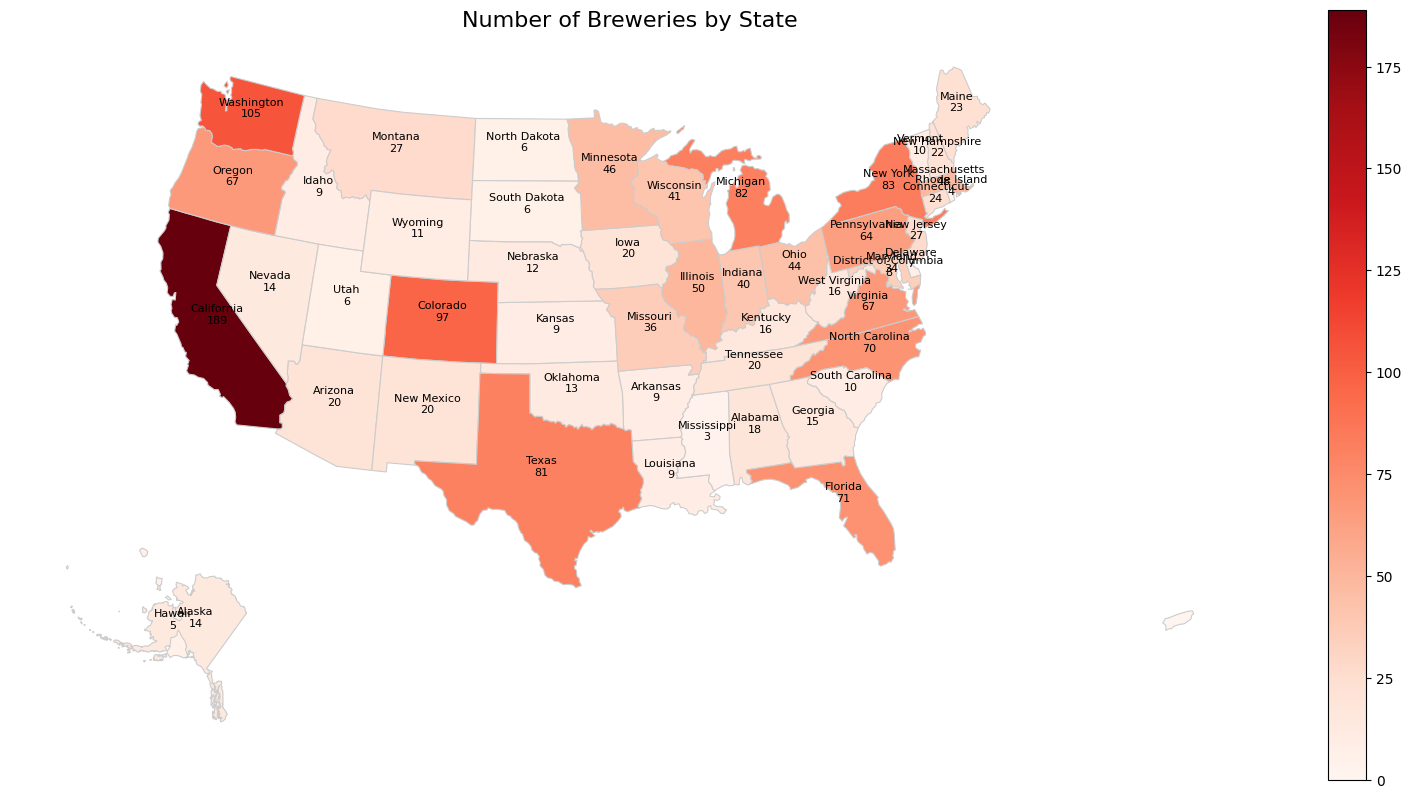

In [19]:
import matplotlib.pyplot as plt
from shapely.affinity import scale, translate

# Resizing the sizes of the polygons to EPSG:2163 to more reprsentative shape sizes
states_resize = states.to_crs("EPSG:2163")

# Separating Alaska and Hawaii from the contigous (border sharing) American states
alaska = states_resize[states_resize["name"] == "Alaska"].copy()
hawaii = states_resize[states_resize["name"] == "Hawaii"].copy()
contiguous = states_resize[~states_resize["name"].isin(["Alaska", "Hawaii"])]

# Rescaling Alaska
alaska["geometry"] = alaska["geometry"].apply(
    lambda geom: scale(geom, xfact=0.35, yfact=0.35, origin="center")
)
# Moving Alaska to bottom left inset
minx, miny, maxx, maxy = contiguous.total_bounds
alaska["geometry"] = alaska["geometry"].apply(
    lambda geom: translate(
        geom,
        xoff=minx - geom.bounds[0] - 500000,
        yoff=miny - geom.bounds[1] - 500000
    )
)

# Moving Hawaii to bottom right
hawaii["geometry"] = hawaii["geometry"].apply(
    lambda geom: translate(
        geom,
        xoff=minx - geom.bounds[0] - 100000,
        yoff=miny - geom.bounds[1] - 150000
    )
)

# Merging the the three modified datasets
states_modified = contiguous._append(alaska)._append(hawaii)

# Spatial Plot
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
states_modified.plot(
    column="brewery_count",
    cmap="Reds",
    linewidth=0.8,
    ax=ax,
    edgecolor="0.8",
    legend=True
)
# Adding Lables
for idx, row in states_modified.iterrows():
    if row["brewery_count"] > 0:
        x, y = row.geometry.centroid.coords[0]
        ax.text(
            x, y,
            f"{row['name']}\n{int(row['brewery_count'])}",
            horizontalalignment="center",
            fontsize=8,
            color="black"
        )
ax.set_title("Number of Breweries by State", fontsize=16)
ax.axis("off")
plt.show()


### Distribution of brewery types across the US

In [20]:
# Count breweries by state and type
grouped = (
    breweries_df[breweries_df["country"] == "United States"]
    .groupby(["state", "brewery_type"])
      .size()
      .reset_index(name="count")
)

print(grouped.head())

     state brewery_type  count
0  Alabama      brewpub      2
1  Alabama       closed      6
2  Alabama        micro      6
3  Alabama     planning      2
4  Alabama      taproom      2


In [21]:
# Brewery Count and Brewery Type Data Distribution

dist_df = grouped.pivot(
    index="state",
    columns="brewery_type",
    values="count"
).fillna(0)

print(dist_df.head())

brewery_type  brewpub  closed  contract  large  micro  nano  planning  \
state                                                                   
Alabama           2.0     6.0       0.0    0.0    6.0   0.0       2.0   
Alaska            3.0     1.0       0.0    0.0    8.0   0.0       0.0   
Arizona           6.0     0.0       1.0    0.0   13.0   0.0       0.0   
Arkansas          3.0     0.0       0.0    0.0    6.0   0.0       0.0   
California       49.0     8.0       6.0    9.0   97.0   0.0      12.0   

brewery_type  proprietor  regional  taproom  
state                                        
Alabama              0.0       0.0      2.0  
Alaska               0.0       1.0      1.0  
Arizona              0.0       0.0      0.0  
Arkansas             0.0       0.0      0.0  
California           2.0       6.0      0.0  


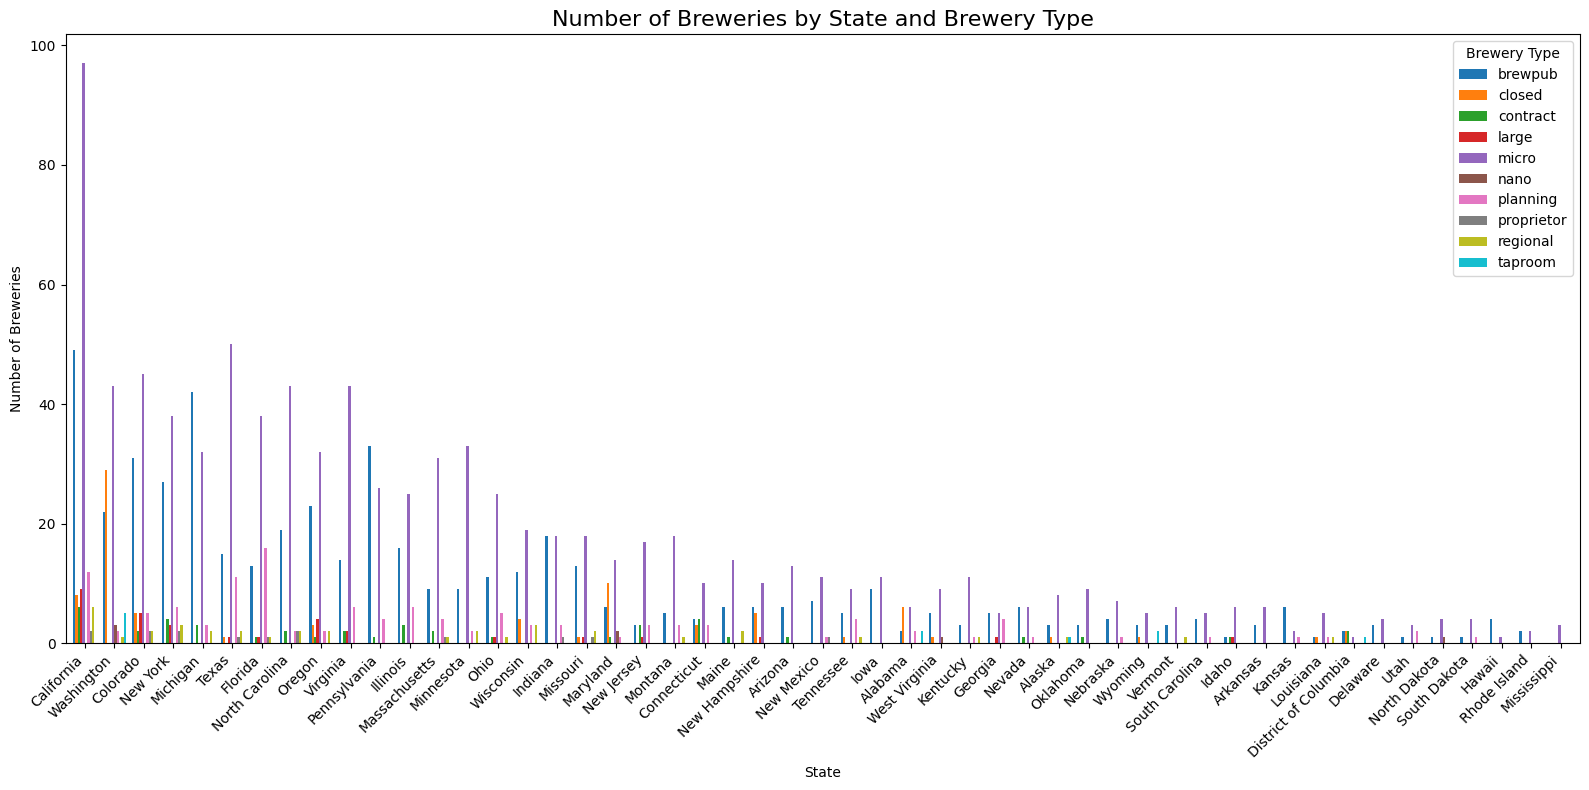

In [22]:
# Sorting the states by total breweries
dist_df["total"] = dist_df.sum(axis=1)
dist_df = dist_df.sort_values("total", ascending=False).drop(columns="total")

# Plotting Distribution of Data
ax = dist_df.plot(
    kind="bar",
    figsize=(16, 8),
    width=0.8
)

ax.set_title("Number of Breweries by State and Brewery Type", fontsize=16)
ax.set_xlabel("State")
ax.set_ylabel("Number of Breweries")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Brewery Type")
plt.tight_layout()
plt.show()

## Consumer Review

In [23]:
# Data Overview
breweries_profile_ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3197 entries, 0 to 3196
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               3197 non-null   object 
 1   Style              3197 non-null   object 
 2   Brewery            3197 non-null   object 
 3   Beer Name (Full)   3197 non-null   object 
 4   Description        3197 non-null   object 
 5   ABV                3197 non-null   float64
 6   Min IBU            3197 non-null   int64  
 7   Max IBU            3197 non-null   int64  
 8   Astringency        3197 non-null   int64  
 9   Body               3197 non-null   int64  
 10  Alcohol            3197 non-null   int64  
 11  Bitter             3197 non-null   int64  
 12  Sweet              3197 non-null   int64  
 13  Sour               3197 non-null   int64  
 14  Salty              3197 non-null   int64  
 15  Fruits             3197 non-null   int64  
 16  Hoppy              3197 

### Summary and Distribution of Review Rating

In [24]:
# Getting Reviews only Data
review_cols = breweries_profile_ratings_df.filter(like="review_")

# Summary statistics
summary_stats = review_cols.describe()

summary_stats

,review_aroma,review_appearance,review_palate,review_taste,review_overall
count,3197.000000,3197.000000,3197.000000,3197.000000,3197.000000
mean,3.638789,3.754393,3.660428,3.702496,3.747522
std,0.503209,0.403416,0.449937,0.510361,0.444288
min,1.509615,1.571429,1.285714,1.214286,1.136364
25%,3.422559,3.604651,3.470021,3.500000,3.566667
50%,3.720183,3.833333,3.741667,3.791667,3.830239
75%,3.978000,4.000000,3.965587,4.033333,4.032847
max,5.000000,4.666667,5.000000,5.000000,5.000000


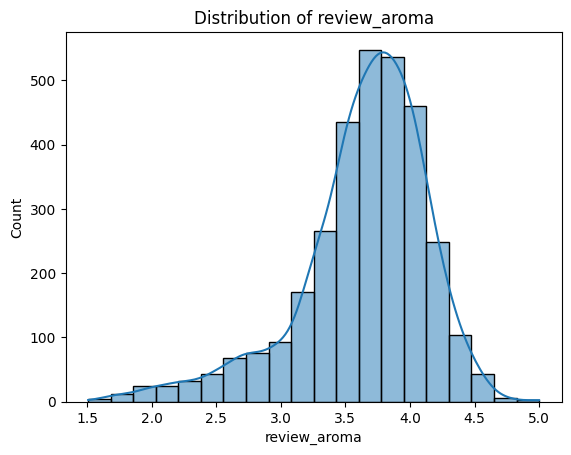

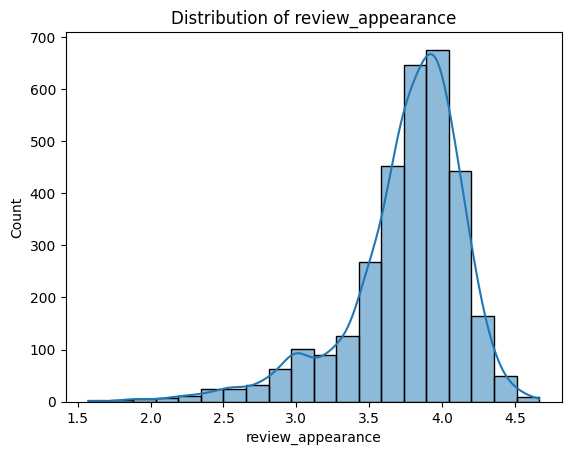

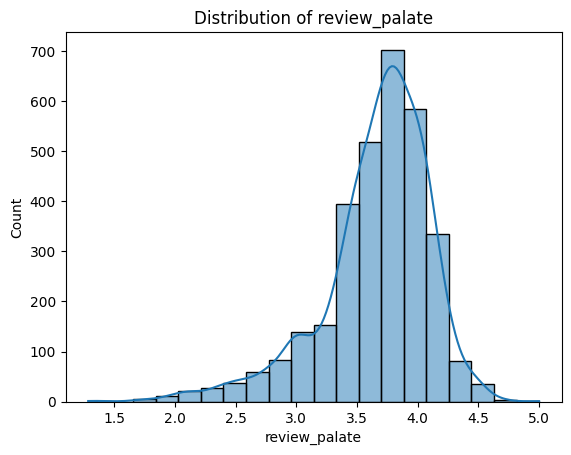

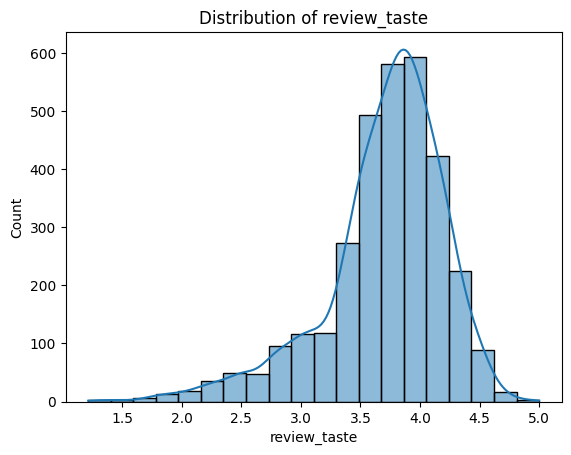

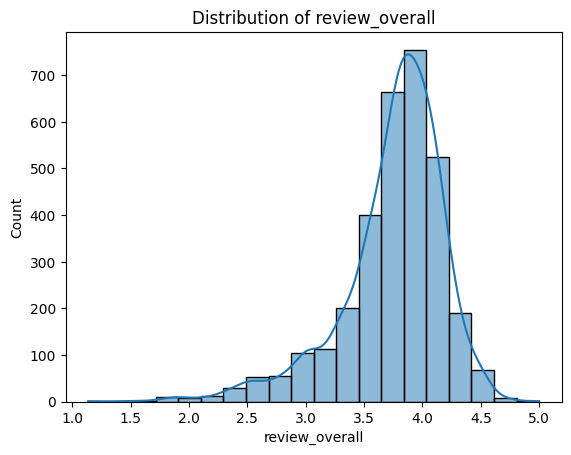

In [25]:
# Ploting distribution of consumer reviews
import seaborn as sns
import matplotlib.pyplot as plt

for col in review_cols.columns:
    plt.figure()
    sns.histplot(breweries_profile_ratings_df[col], bins=20, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Consumer Review Rating and Brewing Style

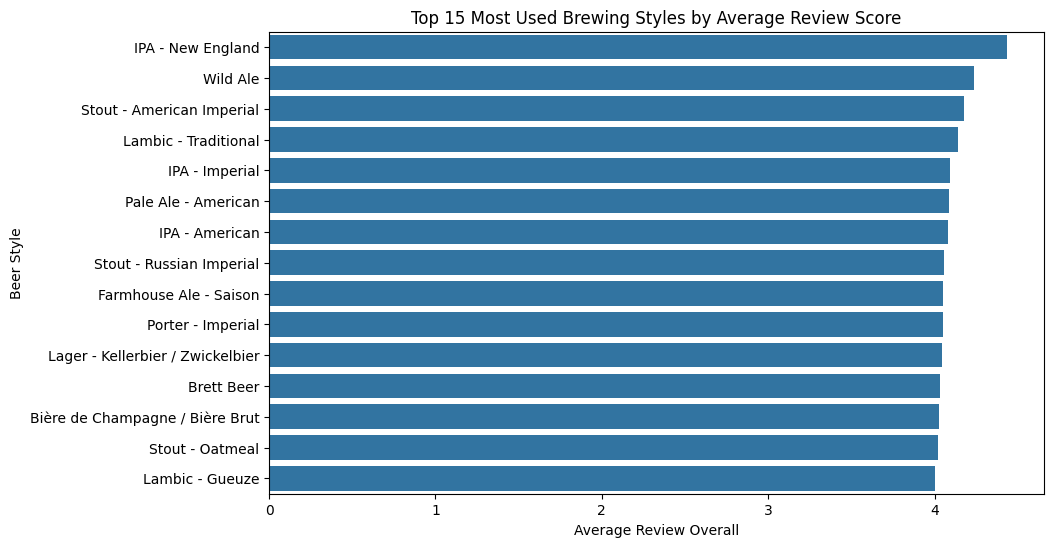

In [26]:
# Average consumer overall review rating across brewing style
## Getting average ratings by brewing style for 15 most used brewing style
top_styles = (
    breweries_profile_ratings_df
    .groupby("Style")["review_overall"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_styles.values, y=top_styles.index)

plt.xlabel("Average Review Overall")
plt.ylabel("Beer Style")
plt.title("Top 15 Most Used Brewing Styles by Average Review Score")

plt.show()

## Random Intercept Cross-lagged Panel Model (RI-CLPM)

In [27]:
%pip install semopy

### Feature Engineering for CLM

In [28]:
# Checking the data types
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             306 non-null    object 
 1   Year              306 non-null    object 
 2   Household_Income  306 non-null    float64
 3   GDP               306 non-null    float64
 4   brewery_count     306 non-null    int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 12.1+ KB


In [29]:
# Converting the year variable to int type
merged_data["Year"] = merged_data["Year"].astype(int)

In [30]:
import pandas as pd
from semopy import Model

# Sorting data by State and Year
merged_data = merged_data.sort_values(["State", "Year"])

In [31]:
# Creating lagged variables per state
merged_data["GDP_lag"] = merged_data.groupby("State")["GDP"].shift(1)
merged_data["Income_lag"] = merged_data.groupby("State")["Household_Income"].shift(1)

In [32]:
# Data Overview
merged_data.head()

,State,Year,Household_Income,GDP,brewery_count,GDP_lag,Income_lag
0,Alabama,2018,61420.0,226263.8,18,NaN,NaN
51,Alabama,2019,68110.0,234798.2,18,226263.8,61420.0
102,Alabama,2020,65600.0,235859.0,18,234798.2,68110.0
153,Alabama,2021,65360.0,260325.0,18,235859.0,65600.0
204,Alabama,2022,63870.0,286873.3,18,260325.0,65360.0


In [33]:
# Dropping first year per state (since lag is NaN)
merged_data = merged_data.dropna(subset=["GDP_lag", "Income_lag"])

In [34]:
# Checking data structure
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 255 entries, 51 to 305
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             255 non-null    object 
 1   Year              255 non-null    int64  
 2   Household_Income  255 non-null    float64
 3   GDP               255 non-null    float64
 4   brewery_count     255 non-null    int64  
 5   GDP_lag           255 non-null    float64
 6   Income_lag        255 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 15.9+ KB


In [35]:
# Log Tranformation of variables
import numpy as np
merged_data['log_GDP'] = np.log1p(merged_data['GDP'])
merged_data['log_GDP_lag'] = np.log1p(merged_data['GDP_lag'])
merged_data['log_income'] = np.log1p(merged_data['Household_Income'])
merged_data['log_income_lag'] = np.log1p(merged_data['Income_lag'])
merged_data['log_brewery_count'] = np.log1p(merged_data['brewery_count'])

### Random Intercept Cross-lagged Panel Model (RI-CLPM) Model

In [47]:
# SEM model specification (RI-CLPM)
# Random intercepts for GDP and Brewery Count
model_desc = """
# Random intercepts
RI_GDP =~ 1*GDP
RI_brewery_count =~ 1*brewery_count

# Cross-lagged effects
GDP ~ a*brewery_count + b*GDP_lag + c*Household_Income
brewery_count ~ d*GDP + e*GDP_lag + f*Household_Income

# Covariances between residuals
GDP ~~ brewery_count
"""

# Initialize model
model = Model(model_desc)

# Fitting model
res = model.fit(merged_data)

# Getting Summary of results
estimates = model.inspect()
print(estimates)


                lval  op              rval      Estimate   Std. Err  \
0                GDP   ~            RI_GDP  1.000000e+00          -   
1      brewery_count   ~  RI_brewery_count  1.000000e+00          -   
2                GDP   ~     brewery_count  1.426594e+01   0.000721   
3                GDP   ~           GDP_lag  1.063477e+00   0.047428   
4                GDP   ~  Household_Income -1.845893e-01   1.954302   
5      brewery_count   ~               GDP -2.449459e-05   0.000003   
6      brewery_count   ~           GDP_lag  7.545488e-05   0.000004   
7      brewery_count   ~  Household_Income  3.212835e-04   0.000087   
8                GDP  ~~     brewery_count  9.298159e-08   0.000001   
9                GDP  ~~               GDP  1.836277e+11        0.0   
10            RI_GDP  ~~            RI_GDP  4.999804e-02        0.0   
11            RI_GDP  ~~  RI_brewery_count  9.298159e-08   0.000001   
12  RI_brewery_count  ~~  RI_brewery_count  3.568833e-03  16.234471   
13    

## Spatial Cross-lagged Panel Models (SCLPM)

In [37]:
import libpysal.weights
from libpysal.weights import Queen
from libpysal.weights import lag_spatial

### Building Spatial Weights for SCLPM

In [38]:
# Checking columns of JSON Spatial Data
print(states.columns)

Index(['id', 'name', 'geometry', 'state', 'brewery_count'], dtype='object')


In [39]:
# Renaming Column
states = states.rename(columns={"name": "State"})

# Removing whitespace in State names
states['State'] = states['State'].str.strip()
merged_data['State'] = merged_data['State'].str.strip()

# Filtering for states in merged data
states = states[states['State'].isin(merged_data['State'].unique())]

# Re-ordering the data
states = states.set_index('State').loc[merged_data['State'].unique()]

In [40]:
# Building weights using contiguity
w = Queen.from_dataframe(states)
w.transform = 'r'

('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 11, ' is an island (no neighbors)')


/tmp/ipykernel_9006/3022731649.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(states)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 1, 11.
  W.__init__(self, neighbors, ids=ids, **kw)


### Feature Engineering for CLM

In [41]:
# computing Lags by Year
merged_data['W_GDP_lag'] = 0
merged_data['W_brewery_count'] = 0

for year in merged_data['Year'].unique():
    mask = merged_data['Year'] == year

    year_data = merged_data.loc[mask].set_index('State').loc[states.index]

    merged_data.loc[mask, 'W_GDP_lag'] = lag_spatial(
        w, year_data['log_GDP_lag']
    )

    merged_data.loc[mask, 'W_brewery_count'] = lag_spatial(
        w, year_data['log_brewery_count']
    )

/tmp/ipykernel_9006/3735211968.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[12.91700686  0.         12.68187663 12.70397452 12.40551705 11.86452197
 12.8635265  13.27668436 13.05992276 12.82763118 12.93179538  0.
 11.87696593 12.53387086 13.1312869  12.42485712 12.37389125 12.84521316
 12.60453403 11.33690879 12.22214119 11.93115397 12.99404677 11.69664844
 12.34346232 12.34314496 10.93953198 11.86922874 12.69082731 11.5848306
 13.04120181 12.87606809 12.62050312 12.92857629 11.51834959 12.62499422
 12.54178873 12.86765337 12.75400084 12.8897235  13.2878726  11.5327431
 12.55498623 11.98799556 11.83878773 12.97476357 12.39982639 11.8300609
 13.07275977 12.96203148 11.62240394]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  merged_data.loc[mask, 'W_GDP_lag'] = lag_spatial(
/tmp/ipykernel_9006/3735211968.py:14: FutureWarning: Setting an item of incompatib

In [42]:
# Checking new data variables
merged_data.head()

,State,Year,Household_Income,GDP,brewery_count,GDP_lag,Income_lag,log_GDP,log_GDP_lag,log_income,log_income_lag,log_brewery_count,W_GDP_lag,W_brewery_count
51,Alabama,2019,68110.0,234798.2,18,226263.8,61420.0,12.366486,12.329461,11.128894,11.025507,2.944439,12.917007,2.870018
102,Alabama,2020,65600.0,235859.0,18,234798.2,68110.0,12.370994,12.366486,11.091346,11.128894,2.944439,12.961583,2.870018
153,Alabama,2021,65360.0,260325.0,18,235859.0,65600.0,12.469690,12.370994,11.087681,11.091346,2.944439,12.967287,2.870018
204,Alabama,2022,63870.0,286873.3,18,260325.0,65360.0,12.566799,12.469690,11.064621,11.087681,2.944439,13.081639,2.870018
255,Alabama,2023,62230.0,309543.8,18,286873.3,63870.0,12.642858,12.566799,11.038609,11.064621,2.944439,13.185725,2.870018


### SCLPM Model

In [43]:
from semopy import Model

# SEM model specification (SCLPM)
# Spatial Cross-lagged Panel Models (SCLPM)
model_desc = """
log_GDP ~ a*log_GDP_lag + b*log_income_lag + c*W_GDP_lag + d*W_brewery_count + e*log_brewery_count
"""

# Initialize Model
model = Model(model_desc)

# Fitting Model
model.fit(merged_data)

# Summary of Results
print(model.inspect())

      lval  op               rval  Estimate  Std. Err     z-value   p-value
0  log_GDP   ~        log_GDP_lag  0.988748  0.007791  126.903443  0.000000
1  log_GDP   ~     log_income_lag -0.015848  0.033873   -0.467862  0.639883
2  log_GDP   ~          W_GDP_lag  0.004552  0.005642    0.806808  0.419777
3  log_GDP   ~    W_brewery_count -0.011001  0.018247   -0.602891  0.546582
4  log_GDP   ~  log_brewery_count  0.011598  0.008867    1.308024  0.190865
5  log_GDP  ~~            log_GDP  0.006471  0.000573   11.291590  0.000000


## Arellano-Bond Difference Generalized Method of Moments (GMM)

In [44]:
%pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.1 MB/s eta 0:00:00


In [45]:
import pandas as pd
import numpy as np
from linearmodels.iv import IVGMM

# Set multi-index (required for panel GMM) and sorting data
merged_data_mi = merged_data.set_index(["State", "Year"])
merged_data_mi = merged_data_mi.sort_index()

# Getting lag 2 for dependent variable
merged_data_mi["log_GDP_lag2"] = (
    merged_data_mi.groupby(level=0)["log_GDP"].shift(2)
)

# Getting First Difference
data_diff = merged_data_mi.groupby(level=0).diff()

# Combining differenced variables with instrument in one dataframe
gmm_data = pd.concat([
    data_diff["log_GDP"],
    data_diff["log_GDP_lag"],
    data_diff[[
        "log_income",
        "log_brewery_count",
        "W_GDP_lag",
        "W_brewery_count"
    ]],
    merged_data_mi["log_GDP_lag2"]
], axis=1).dropna()

# Removing columns with no variation (fixes rank issue)
gmm_data = gmm_data.loc[:, gmm_data.std() > 0]

# Initializing Variables
# Dependent variable
y = gmm_data["log_GDP"]

# Endogenous regressor
endog = gmm_data["log_GDP_lag"]

# Exogenous variables (differences)
exog_vars = ["log_income", "log_brewery_count", "W_GDP_lag", "W_brewery_count"]
exog_vars = [v for v in exog_vars if v in gmm_data.columns]
exog = gmm_data[exog_vars]

# Aligning instrument to differenced dataframe
instruments = gmm_data["log_GDP_lag2"]

# Estimating GMM Model
model = IVGMM(
    dependent=y,
    exog=exog,
    endog=endog,
    instruments=instruments
)

results = model.fit(cov_type="robust")

print(results.summary)


                          IV-GMM Estimation Summary                           
Dep. Variable:                log_GDP   R-squared:                     -53.047
Estimator:                     IV-GMM   Adj. R-squared:                -54.128
No. Observations:                 153   F-statistic:                    4.6641
Date:                Sat, Mar 07 2026   P-value (F-stat)                0.1981
Time:                        13:14:34   Distribution:                  chi2(3)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
log_income     -0.6635     0.7838    -0.8466     0.3972     -2.1996      0.8726
W_GDP_lag      -20.492     23.163    -0.8847    